In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv")
df.head()

,record_id,customer_id,subscription_id,subscription_plan,plan_category,subscription_start_date,subscription_end_date,billing_cycle,subscription_fee,discount_percent,...,monthly_active_user,weekly_active_user,start_year,start_month,start_day,start_quarter,end_year,end_month,end_day,end_quarter
0,REC000001,CUST000001,SUB000001,Growth,Standard,2023-05-18,2023-06-17,Monthly,299,0,...,No,No,2023,5,18,2,2023,6,17,2
1,REC000002,CUST000002,SUB000002,Growth,Standard,2024-03-04,2024-04-03,Quarterly,299,15,...,No,Yes,2024,3,4,1,2024,4,3,2
2,REC000003,CUST000003,SUB000003,Growth,Standard,2023-10-28,2023-11-27,Quarterly,299,5,...,Yes,No,2023,10,28,4,2023,11,27,4
3,REC000004,CUST000004,SUB000004,Growth,Standard,2023-02-12,2023-05-13,Quarterly,299,0,...,No,Yes,2023,2,12,1,2023,5,13,2
4,REC000005,CUST000005,SUB000005,Growth,Standard,2024-02-15,2025-02-14,Quarterly,299,5,...,Yes,Yes,2024,2,15,1,2025,2,14,1


In [3]:
print(df.shape)

(20000, 59)


In [6]:
## outliers Analysis using IQR 
columns = ["discount_percent",
           "tax_amount",
           "final_amount_paid"]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("="*50)
    print("Column :", col)
    print("Lower Limit :", lower)
    print("Upper Limit :", upper)
    print("Outliers :", len(outliers))

Column : discount_percent
Lower Limit : -10.0
Upper Limit : 30.0
Outliers : 0
Column : tax_amount
Lower Limit : -90.57
Upper Limit : 272.95
Outliers : 3000
Column : final_amount_paid
Lower Limit : -593.77
Upper Limit : 1789.35
Outliers : 3000


In [7]:
## outliers using z-sore 
for col in columns:
    z = np.abs(zscore(df[col]))

    outliers = df[z > 3]

    print("="*50)
    print("Column :", col)
    print("Z-score Outliers :", len(outliers))

Column : discount_percent
Z-score Outliers : 0
Column : tax_amount
Z-score Outliers : 0
Column : final_amount_paid
Z-score Outliers : 0


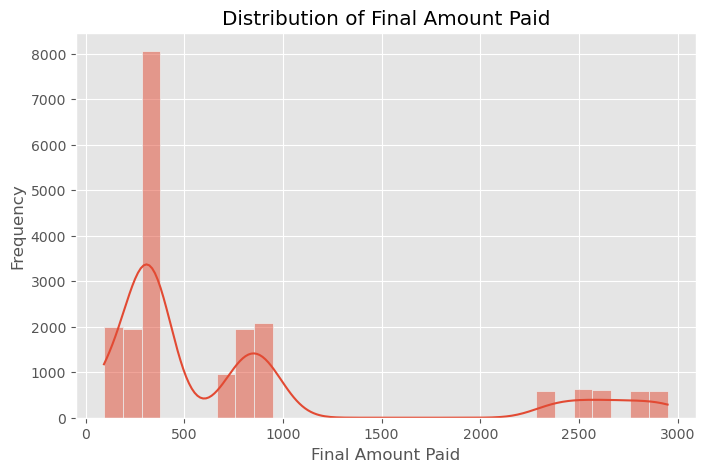

In [8]:
## Distribution charts 
plt.figure(figsize=(8,5))
sns.histplot(df["final_amount_paid"], bins=30, kde=True)
plt.title("Distribution of Final Amount Paid")
plt.xlabel("Final Amount Paid")
plt.ylabel("Frequency")
plt.show()

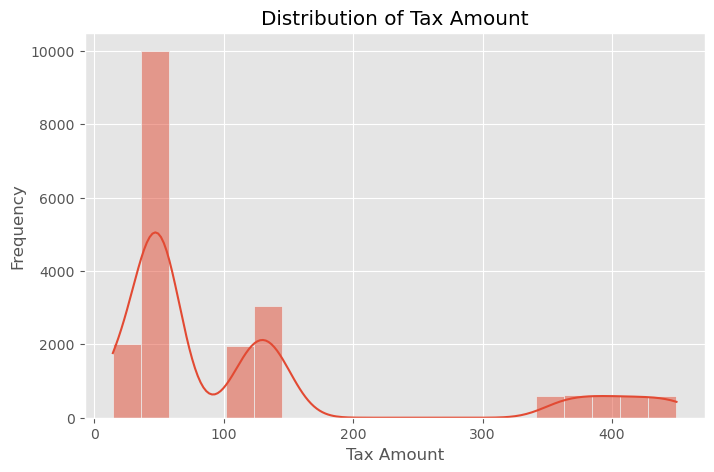

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["tax_amount"], bins=20, kde=True)
plt.title("Distribution of Tax Amount")
plt.xlabel("Tax Amount")
plt.ylabel("Frequency")
plt.show()

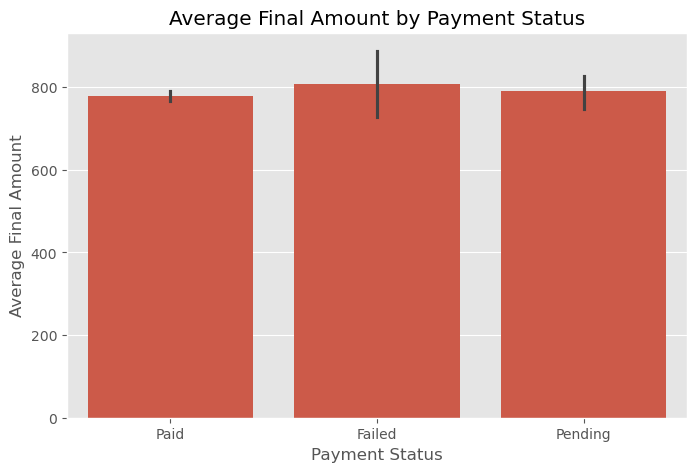

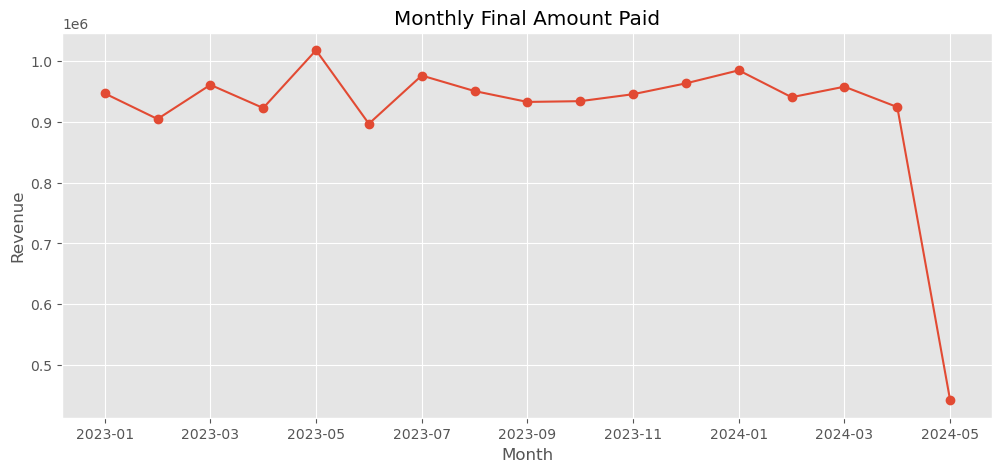

In [9]:
## Trend chart 
df["subscription_start_date"] = pd.to_datetime(df["subscription_start_date"])
monthly = df.groupby( df["subscription_start_date"].dt.to_period("M"))["final_amount_paid"].sum()
monthly.index = monthly.index.astype(str)
plt.figure(figsize=(12,5))

monthly.plot(marker="o")
plt.title("Monthly Final Amount Paid")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

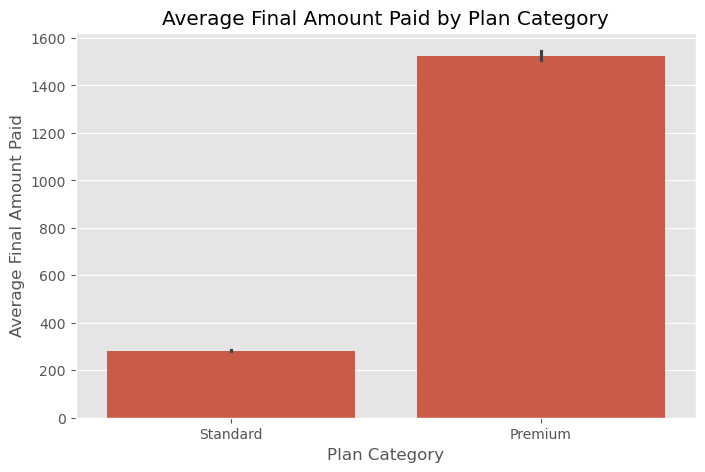

In [10]:
## comparision chart
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x="plan_category",
            y="final_amount_paid",
            estimator=np.mean)

plt.title("Average Final Amount Paid by Plan Category")
plt.xlabel("Plan Category")
plt.ylabel("Average Final Amount Paid")
plt.show()

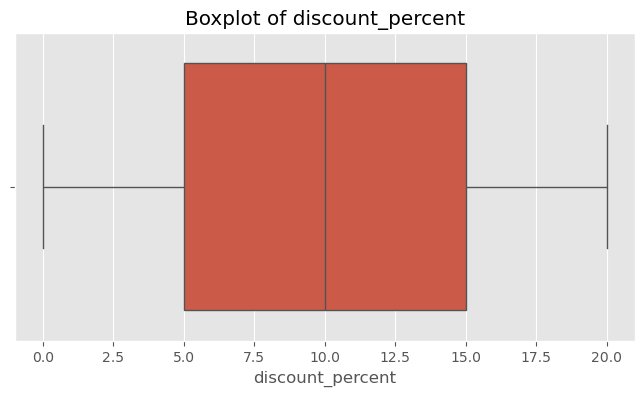

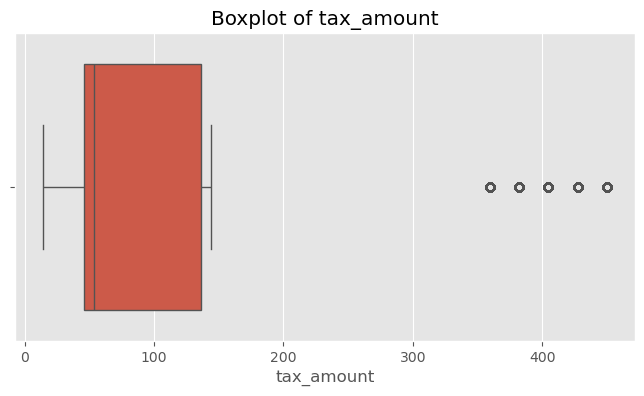

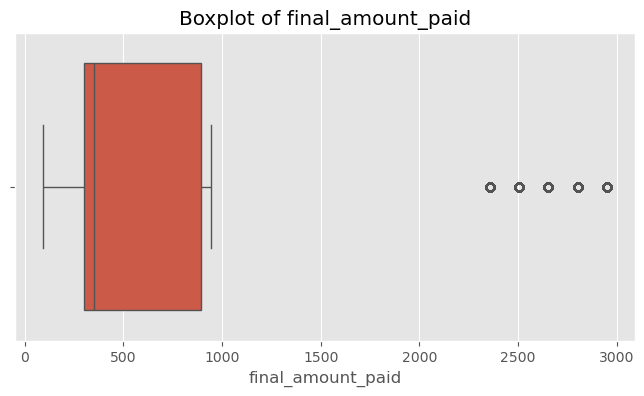

In [12]:
## Box plots 
for col in columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

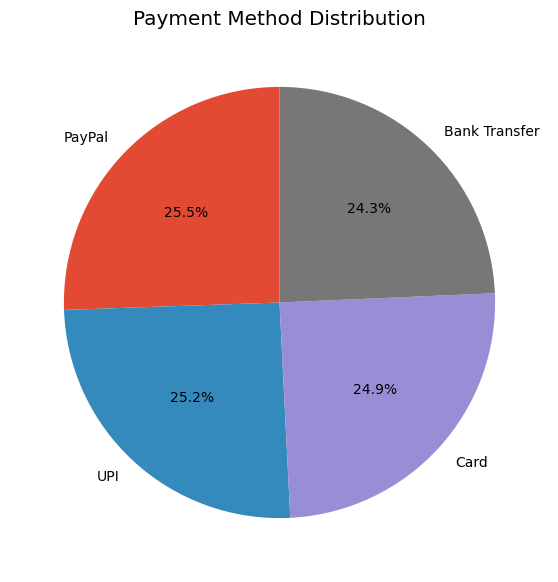

In [17]:
## pie chart 
payment = df["payment_method"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    payment,
    labels=payment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

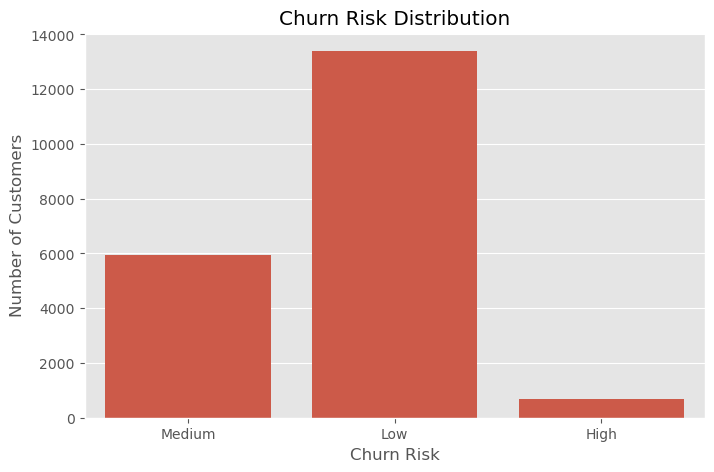

In [19]:
## countplot 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="churn_risk"
)
plt.title("Churn Risk Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.show()

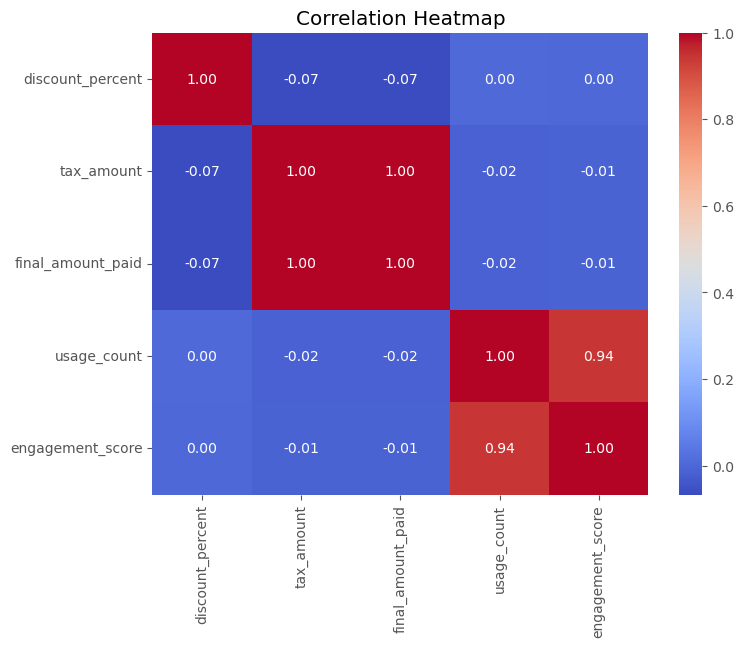

In [20]:
## HeatMap 
plt.figure(figsize=(8,6))
corr = df[
    [
        "discount_percent",
        "tax_amount",
        "final_amount_paid",
        "usage_count",
        "engagement_score"
    ]
].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
df[columns].describe()

,discount_percent,tax_amount,final_amount_paid
count,20000.000000,20000.000000,20000.000000
mean,9.895500,118.983996,779.995201
std,7.050111,126.459456,829.012518
min,0.000000,14.260000,93.460000
25%,5.000000,45.750000,299.900000
50%,10.000000,53.820000,352.820000
75%,15.000000,136.630000,895.680000
max,20.000000,449.820000,2948.820000


In [22]:
df.to_csv(
r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv",
index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


 ## Insights 

- Discounts are applied consistently, with no abnormal discount values detected, indicating a controlled pricing strategy.
 - Premium subscriptions contribute a significant share of revenue, as higher payment values were identified by the IQR method in final_amount_paid.
- Monthly subscription activity varies over time, suggesting fluctuations in customer acquisition or subscription renewals that should be monitored.
- Higher plan categories generate greater average revenue, making premium plans a key contributor to business growth.
- Customers prefer specific payment methods, so maintaining reliable support for these payment options can improve the payment experience.
- The churn risk distribution shows that some customers are at higher risk, highlighting the need for targeted retention campaigns.
- Tax amount increases with the final payment amount, indicating a consistent relationship between subscription value and tax calculation.
- Most customer payments fall in the lower to mid-price range, while a smaller number of premium subscriptions generate higher revenue.
- Financial metrics are stable overall, as no extreme outliers were detected using the Z-score method, indicating consistent pricing and billing practices.
- The correlation analysis shows that final payment is more closely related to tax amount than to discount percentage, suggesting that subscription price has a stronger impact on revenue than discounts.